In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import kagglehub
from pathlib import Path

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# download dataset
path = Path(kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)) / "IMDB Dataset.csv"

df = pd.read_csv(path)

# labels
df["label"] = (df["sentiment"] == "positive").astype(int)

texts = df["review"].astype(str).values
labels = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

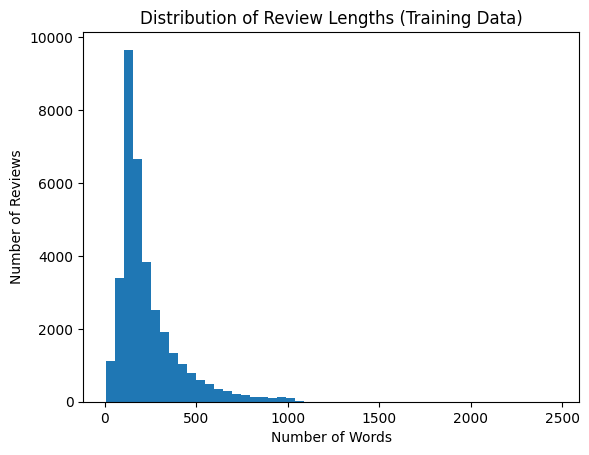

Average length: 230.81571428571428
Max length: 2470


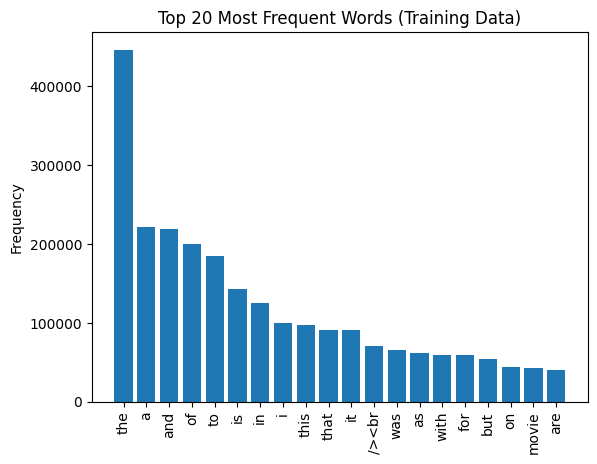

In [5]:
import matplotlib.pyplot as plt

# compute review lengths
train_lengths = [len(text.split()) for text in X_train]

plt.figure()
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Review Lengths (Training Data)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

print("Average length:", np.mean(train_lengths))
print("Max length:", np.max(train_lengths))

from collections import Counter

all_words = []

for text in X_train:
    all_words.extend(text.lower().split())

word_counts = Counter(all_words)
top_words = word_counts.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Words (Training Data)")
plt.ylabel("Frequency")
plt.show()

In [6]:
all_text = "".join(X_train)
chars = sorted(set(all_text))

char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"] = 0

vocab_size = len(char2idx)
MAX_LEN = 400

def encode(text):
    seq = [char2idx.get(c,0) for c in text[:MAX_LEN]]
    if len(seq) < MAX_LEN:
        seq += [0]*(MAX_LEN-len(seq))
    return seq

X_train = np.array([encode(t) for t in X_train])
X_val   = np.array([encode(t) for t in X_val])
X_test  = np.array([encode(t) for t in X_test])

class CharDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

g = torch.Generator()
g.manual_seed(SEED)

train_loader = torch.utils.data.DataLoader(
    CharDataset(X_train, y_train), batch_size=128, shuffle=True, generator=g
)

val_loader = torch.utils.data.DataLoader(
    CharDataset(X_val, y_val), batch_size=128, generator=g
)

test_loader = torch.utils.data.DataLoader(
    CharDataset(X_test, y_test), batch_size=128, generator=g
)

class CharRNN(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 64)
        self.rnn = nn.RNN(64, 192, batch_first=True)
        self.fc = nn.Linear(192, 1)

    def forward(self, x):

        x = self.embedding(x)

        _, hidden = self.rnn(x)

        out = self.fc(hidden.squeeze(0))

        return torch.sigmoid(out)


class CharLSTM(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 64)
        self.rnn = nn.LSTM(64, 192, batch_first=True)
        self.fc = nn.Linear(192, 1)

    def forward(self, x):

        x = self.embedding(x)

        _, (h_n, _) = self.rnn(x)

        out = self.fc(h_n[0]) 

        return torch.sigmoid(out)

class CharGRU(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 64)
        self.rnn = nn.GRU(64, 192, batch_first=True)
        self.fc = nn.Linear(192, 1)

    def forward(self, x):

        x = self.embedding(x)

        _, hidden = self.rnn(x)

        out = self.fc(hidden.squeeze(0))

        return torch.sigmoid(out)

Epoch 1: Train Loss = 0.6969, Val Loss = 0.6945, Val Accuracy = 0.5040
Epoch 2: Train Loss = 0.6931, Val Loss = 0.6942, Val Accuracy = 0.5023
Epoch 3: Train Loss = 0.6923, Val Loss = 0.6951, Val Accuracy = 0.5073
Epoch 4: Train Loss = 0.6927, Val Loss = 0.6949, Val Accuracy = 0.4980
Epoch 5: Train Loss = 0.6922, Val Loss = 0.6949, Val Accuracy = 0.5073
Epoch 6: Train Loss = 0.6949, Val Loss = 0.7019, Val Accuracy = 0.4827
Epoch 7: Train Loss = 0.6955, Val Loss = 0.6939, Val Accuracy = 0.5017
Epoch 8: Train Loss = 0.6949, Val Loss = 0.6943, Val Accuracy = 0.4959
Epoch 9: Train Loss = 0.6949, Val Loss = 0.7005, Val Accuracy = 0.5016
Epoch 10: Train Loss = 0.6939, Val Loss = 0.6940, Val Accuracy = 0.4937


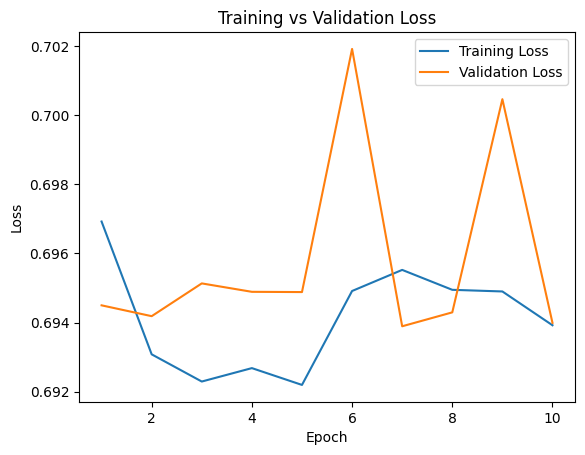

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelrnn = CharRNN(vocab_size).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(modelrnn.parameters(), lr=0.001)

EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    modelrnn.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = modelrnn(X).squeeze()
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    modelrnn.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            pred = modelrnn(X).squeeze()
            loss = criterion(pred, y)
            val_loss += loss.item()

            # Compute accuracy
            predicted_labels = (pred >= 0.5).float()
            correct += (predicted_labels == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_accuracy:.4f}")

plt.figure()

plt.plot(range(1, EPOCHS + 1), train_losses, label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

Epoch 1: Train Loss = 0.6946, Val Loss = 0.6935, Val Accuracy = 0.5067
Epoch 2: Train Loss = 0.6924, Val Loss = 0.6944, Val Accuracy = 0.5055
Epoch 3: Train Loss = 0.6916, Val Loss = 0.6930, Val Accuracy = 0.5160
Epoch 4: Train Loss = 0.6896, Val Loss = 0.6921, Val Accuracy = 0.5301
Epoch 5: Train Loss = 0.6811, Val Loss = 0.6653, Val Accuracy = 0.6059
Epoch 6: Train Loss = 0.5789, Val Loss = 0.5343, Val Accuracy = 0.7304
Epoch 7: Train Loss = 0.4822, Val Loss = 0.4906, Val Accuracy = 0.7591
Epoch 8: Train Loss = 0.4322, Val Loss = 0.4788, Val Accuracy = 0.7673
Epoch 9: Train Loss = 0.3877, Val Loss = 0.4951, Val Accuracy = 0.7645
Epoch 10: Train Loss = 0.3456, Val Loss = 0.4752, Val Accuracy = 0.7800


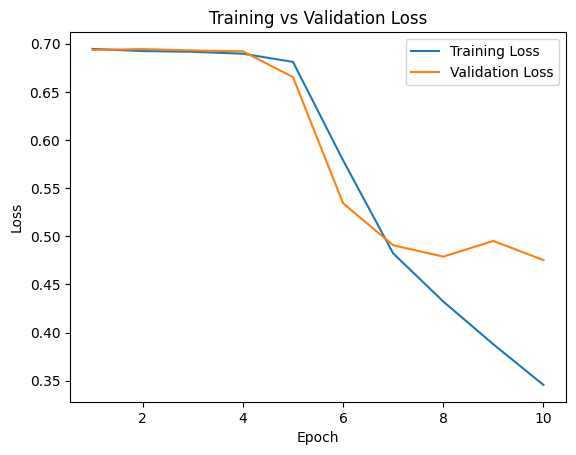

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelgru = CharGRU(vocab_size).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(modelgru.parameters(), lr=0.001)

EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    modelgru.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = modelgru(X).squeeze()
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    modelgru.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            pred = modelgru(X).squeeze()
            loss = criterion(pred, y)
            val_loss += loss.item()

            # Compute accuracy
            predicted_labels = (pred >= 0.5).float()  # Threshold at 0.5
            correct += (predicted_labels == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_accuracy:.4f}")

plt.figure()

plt.plot(range(1, EPOCHS + 1), train_losses, label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

Epoch 1: Train Loss = 0.6936, Val Loss = 0.6928, Val Accuracy = 0.5055
Epoch 2: Train Loss = 0.6919, Val Loss = 0.6930, Val Accuracy = 0.5151
Epoch 3: Train Loss = 0.6910, Val Loss = 0.6939, Val Accuracy = 0.5193
Epoch 4: Train Loss = 0.6891, Val Loss = 0.6915, Val Accuracy = 0.5263
Epoch 5: Train Loss = 0.6883, Val Loss = 0.6938, Val Accuracy = 0.5085
Epoch 6: Train Loss = 0.6868, Val Loss = 0.6966, Val Accuracy = 0.5189
Epoch 7: Train Loss = 0.6881, Val Loss = 0.6937, Val Accuracy = 0.5120
Epoch 8: Train Loss = 0.6836, Val Loss = 0.6947, Val Accuracy = 0.5388
Epoch 9: Train Loss = 0.6746, Val Loss = 0.6940, Val Accuracy = 0.5348
Epoch 10: Train Loss = 0.6671, Val Loss = 0.6929, Val Accuracy = 0.5404


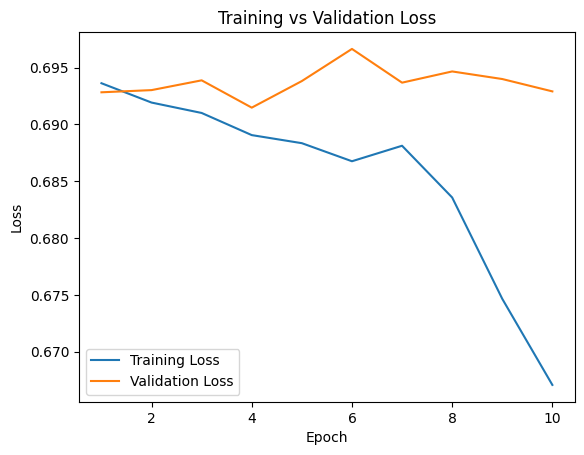

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modellstm = CharLSTM(vocab_size).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(modellstm.parameters(), lr=0.001)

EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    modellstm.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = modellstm(X).squeeze()
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    modellstm.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            pred = modellstm(X).squeeze()
            loss = criterion(pred, y)
            val_loss += loss.item()

            # Compute accuracy
            predicted_labels = (pred >= 0.5).float()
            correct += (predicted_labels == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_accuracy:.4f}")

plt.figure()

plt.plot(range(1, EPOCHS + 1), train_losses, label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [10]:

for model in [modelrnn,modellstm,modelgru]:
    correct = 0
    total = 0
    
    model.eval()
    
    with torch.no_grad():
    
        for X,y in test_loader:
    
            X = X.to(device)
    
            pred = model(X).squeeze()
    
            preds = (pred > 0.5).cpu()
    
            correct += (preds == y).sum().item()
            total += len(y)
    
    accuracy = correct / total
    print("Test Accuracy:", accuracy)

Test Accuracy: 0.5002666666666666
Test Accuracy: 0.5289333333333334
Test Accuracy: 0.7856
